In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
widebinary_raw = pd.read_parquet("../widebinaries/wdms_widebinaries.pqt")
widebinary_better = pd.read_parquet("../widebinaries/widebinary_fluxes.pqt")
widebinary_raw = widebinary_raw[widebinary_raw.wd_source_id.isin(widebinary_better["GaiaEDR3"])]

tyler_data = pd.read_csv("../widebinaries/data/tyler_wdms.csv")
tyler_data = tyler_data[tyler_data.source_id.isin(widebinary_better["GaiaEDR3"])]
list(tyler_data.keys())

['source_id',
 'ref_epoch',
 'ra',
 'ra_error',
 'dec',
 'dec_error',
 'parallax',
 'parallax_error',
 'parallax_over_error',
 'pm',
 'pmra',
 'pmra_error',
 'pmdec',
 'pmdec_error',
 'astrometric_params_solved',
 'ruwe',
 'duplicated_source',
 'phot_g_n_obs',
 'phot_g_mean_flux',
 'phot_g_mean_flux_error',
 'phot_g_mean_flux_over_error',
 'phot_g_mean_mag',
 'phot_bp_n_obs',
 'phot_bp_mean_flux',
 'phot_bp_mean_flux_error',
 'phot_bp_mean_flux_over_error',
 'phot_bp_mean_mag',
 'phot_rp_n_obs',
 'phot_rp_mean_flux',
 'phot_rp_mean_flux_error',
 'phot_rp_mean_flux_over_error',
 'phot_rp_mean_mag',
 'phot_bp_n_contaminated_transits',
 'phot_bp_n_blended_transits',
 'phot_rp_n_contaminated_transits',
 'phot_rp_n_blended_transits',
 'phot_proc_mode',
 'phot_bp_rp_excess_factor',
 'bp_rp',
 'bp_g',
 'g_rp',
 'l',
 'b',
 'ecl_lon',
 'ecl_lat',
 'pairdistance',
 'sep_AU',
 'Sigma18',
 'R_chance_align',
 'meanAV',
 'minAV',
 'maxAV',
 'flag_ext',
 'objid',
 'u',
 'g',
 'r',
 'i',
 'z',
 'err_

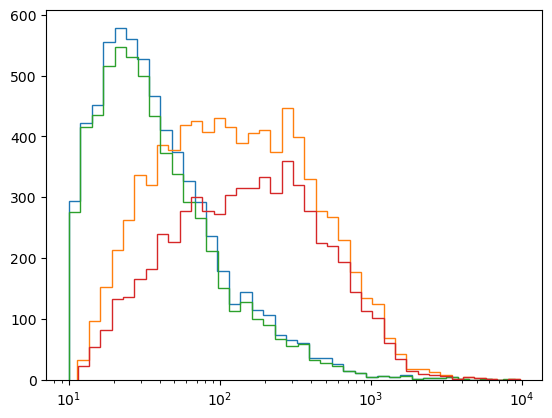

In [10]:
fig, ax = plt.subplots()
snr1 = widebinary_raw["Plx"] / widebinary_raw["e_Plx"]
ax.hist(snr1, bins=np.logspace(np.log10(snr1.min()), np.log10(snr1.max()), 40), histtype='step');

snr2 = widebinary_better["parallax"] / widebinary_better["parallax_error"]
widebinary_better["my_wtd_plx"] = widebinary_better["parallax"]
ax.hist(snr2, bins=np.logspace(np.log10(snr2.min()), np.log10(snr2.max()), 40), histtype='step');

snr3 = tyler_data["parallax_over_error"]
ax.hist(snr3, bins=np.logspace(np.log10(snr3.min()), np.log10(snr3.max()), 40), histtype='step');

snr4 = tyler_data["wtd_par"] / tyler_data["e_wtd_par"]
ax.hist(snr4, bins=np.logspace(np.log10(snr4.min()), np.log10(snr4.max()), 40), histtype='step');

ax.set_xscale('log')


In [ ]:
merge = pd.merge(tyler_data, widebinary_better, left_on="source_id", right_on="gaia_dr3_source_id")

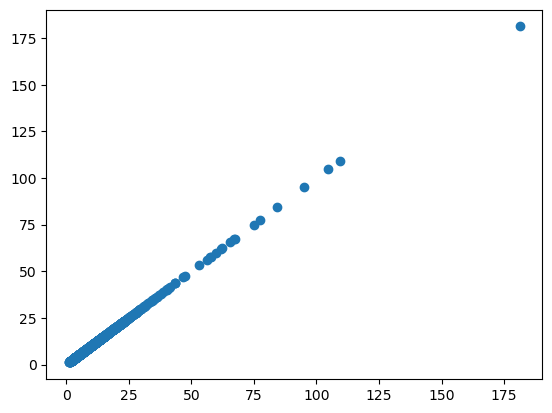

In [12]:
plt.scatter(merge["wtd_par"], merge["my_wtd_plx"])